In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df=pd.read_csv('/content/Flight_Fare - Sheet1.csv')

# Domain Analysis
* The dataset belongs to the aviation and travel domain, specifically focused on commercial flight pricing.

* Flight prices depend on numerous real-world factors such as airline type, source and destination cities, number of stops, travel duration, and departure/arrival timings.

* These features reflect practical pricing patterns used by airlines, including demand, travel distance, flight class, and operational constraints.

* The problem aims to build a model that can predict flight ticket prices based on these collected features, helping users or companies understand price behavior and make cost-effective decisions.


## Features In Dataset
* Airline - Name of the airline operating the flight (e.g., IndiGo, Air India).
* Date_of_Journey - The date on which the passenger is scheduled to travel.
* Source - The city from where the journey begins.
* Destination - The city where the passenger wants to reach.
* Route - The complete flight route showing all stop cities between source and destination.
* Dep_Time - Scheduled departure time of the flight from the source airport.
* Arrival_Time - Scheduled arrival time of the flight at the destination airport.
* Duration - Total travel time from departure to arrival, including layovers.
* Total_Stops - Number of stops between source and destination (non-stop, 1 stop, 2 stops, etc.).
* Additional_Info - Extra details about the flight (meal info, baggage included, layovers, etc.).
### Target Variable
* Price - The flight ticket cost — target variable for prediction.


#Create a predictive model using machine learning techniques to predict the Flight ticket cost.

#Basic Check

In [9]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [10]:
df.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [11]:
df.shape

(10683, 11)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


* We can see from the data info that except target column all other columns are dtype as object and target variable is dtype as int.

* Also there is no null values.

In [13]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [14]:
df.describe(include='O')

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info
count,10683,10683,10683,10683,10682,10683,10683,10683,10682,10683
unique,12,44,5,6,128,222,1343,368,5,10
top,Jet Airways,18/05/2019,Delhi,Cochin,DEL → BOM → COK,18:55,19:00,2h 50m,1 stop,No info
freq,3849,504,4537,4537,2376,233,423,550,5625,8345


## Summary
* The dataset contains 10,683 rows and 11 columns, with Price as the target variable.

* Most columns are categorical (object type), while Price is numeric.

* No null values were found, but a few columns like Route and Total_Stops had one missing entry, which was handled using mode.

* Initial inspection showed that several columns (Date, Time, Duration) required preprocessing and feature extraction before model building.

#Feature Engineering

##Data preprocessing

* Now we have to check for need any cleaning in data or not.

In [15]:
for i in df:
  print(df[i].unique())

  print('------------------------')

['IndiGo' 'Air India' 'Jet Airways' 'SpiceJet' 'Multiple carriers' 'GoAir'
 'Vistara' 'Air Asia' 'Vistara Premium economy' 'Jet Airways Business'
 'Multiple carriers Premium economy' 'Trujet']
------------------------
['24/03/2019' '1/05/2019' '9/06/2019' '12/05/2019' '01/03/2019'
 '24/06/2019' '12/03/2019' '27/05/2019' '1/06/2019' '18/04/2019'
 '9/05/2019' '24/04/2019' '3/03/2019' '15/04/2019' '12/06/2019'
 '6/03/2019' '21/03/2019' '3/04/2019' '6/05/2019' '15/05/2019'
 '18/06/2019' '15/06/2019' '6/04/2019' '18/05/2019' '27/06/2019'
 '21/05/2019' '06/03/2019' '3/06/2019' '15/03/2019' '3/05/2019'
 '9/03/2019' '6/06/2019' '24/05/2019' '09/03/2019' '1/04/2019'
 '21/04/2019' '21/06/2019' '27/03/2019' '18/03/2019' '12/04/2019'
 '9/04/2019' '1/03/2019' '03/03/2019' '27/04/2019']
------------------------
['Banglore' 'Kolkata' 'Delhi' 'Chennai' 'Mumbai']
------------------------
['New Delhi' 'Banglore' 'Cochin' 'Kolkata' 'Delhi' 'Hyderabad']
------------------------
['BLR → DEL' 'CCU → IXR → B

* So from all columns unique values we have found that there are some currpted data in 'route', 'stop' and 'additional info' columns.

In [16]:
df.loc[df['Route'].isnull()]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
9039,Air India,6/05/2019,Delhi,Cochin,NaN,09:45,09:25 07 May,23h 40m,NaN,No info,7480


In [17]:
df['Route'].fillna(df['Route'].mode()[0],inplace=True)

/tmp/ipython-input-3777004150.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Route'].fillna(df['Route'].mode()[0],inplace=True)


In [18]:
df.Route.unique()

array(['BLR → DEL', 'CCU → IXR → BBI → BLR', 'DEL → LKO → BOM → COK',
       'CCU → NAG → BLR', 'BLR → NAG → DEL', 'CCU → BLR',
       'BLR → BOM → DEL', 'DEL → BOM → COK', 'DEL → BLR → COK',
       'MAA → CCU', 'CCU → BOM → BLR', 'DEL → AMD → BOM → COK',
       'DEL → PNQ → COK', 'DEL → CCU → BOM → COK', 'BLR → COK → DEL',
       'DEL → IDR → BOM → COK', 'DEL → LKO → COK',
       'CCU → GAU → DEL → BLR', 'DEL → NAG → BOM → COK',
       'CCU → MAA → BLR', 'DEL → HYD → COK', 'CCU → HYD → BLR',
       'DEL → COK', 'CCU → DEL → BLR', 'BLR → BOM → AMD → DEL',
       'BOM → DEL → HYD', 'DEL → MAA → COK', 'BOM → HYD',
       'DEL → BHO → BOM → COK', 'DEL → JAI → BOM → COK',
       'DEL → ATQ → BOM → COK', 'DEL → JDH → BOM → COK',
       'CCU → BBI → BOM → BLR', 'BLR → MAA → DEL',
       'DEL → GOI → BOM → COK', 'DEL → BDQ → BOM → COK',
       'CCU → JAI → BOM → BLR', 'CCU → BBI → BLR', 'BLR → HYD → DEL',
       'DEL → TRV → COK', 'CCU → IXR → DEL → BLR',
       'DEL → IXU → BOM → COK', 'CCU 

* Now we can see there no 'NaN' value in Route column

In [19]:
df.loc[df['Total_Stops'].isnull()]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
9039,Air India,6/05/2019,Delhi,Cochin,DEL → BOM → COK,09:45,09:25 07 May,23h 40m,NaN,No info,7480


In [20]:
df['Total_Stops'].fillna(df['Total_Stops'].mode()[0],inplace=True)

/tmp/ipython-input-2037983482.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Total_Stops'].fillna(df['Total_Stops'].mode()[0],inplace=True)


In [21]:
df.Additional_Info.value_counts()

,count
Additional_Info,
No info,8345
In-flight meal not included,1982
No check-in baggage included,320
1 Long layover,19
Change airports,7
Business class,4
No Info,3
1 Short layover,1
Red-eye flight,1


* There are majorly data is 'No info', 'In-flight meal not included' and 'No check-in baggage included'.
* But this info is affecting the price so we don't take risk to drop this column.
* So we combine other data into one combine category. So after that we have 4 types of values in Addintional info column.

In [22]:
df['Additional_Info'] = df['Additional_Info'].str.lower().replace('no info', 'no info')


In [23]:
rare_labels = df['Additional_Info'].value_counts(normalize=True)
rare_labels = rare_labels[rare_labels < 0.01].index
df['Additional_Info'] = df['Additional_Info'].replace(rare_labels, 'other')

In [24]:
df.Additional_Info.value_counts()

,count
Additional_Info,
no info,8348
in-flight meal not included,1982
no check-in baggage included,320
other,33


#EDA

## 1. Univariate Analysis

In [25]:
df.head()


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,no info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,no info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,no info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,no info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,no info,13302


In [26]:
from warnings import filterwarnings
filterwarnings('ignore')

In [27]:
cat_cols = ['Airline','Source','Destination','Total_Stops','Additional_Info']

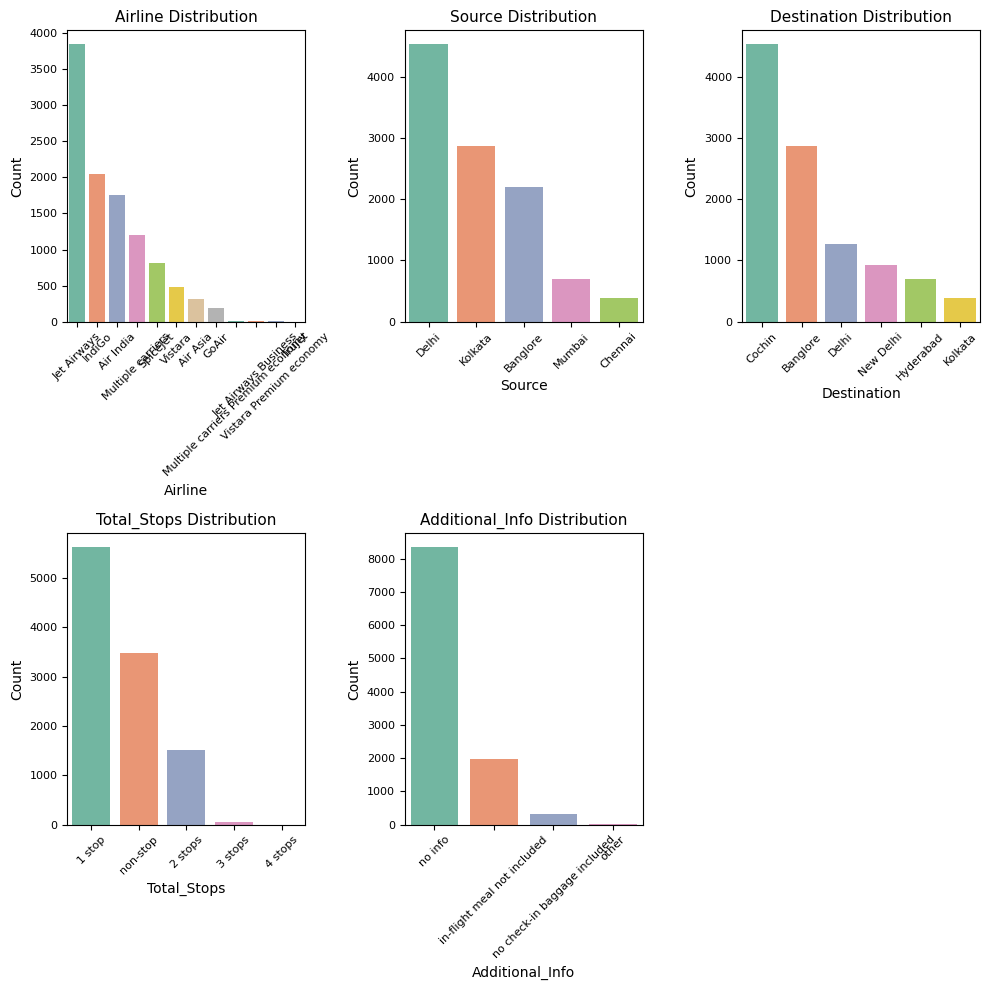

In [28]:
plt.figure(figsize=(10,10))
plotnum = 1
for i in cat_cols:
    if plotnum <= 6:
        plt.subplot(2, 3, plotnum)
        sns.countplot(data=df, x=i, order=df[i].value_counts().index, palette="Set2")
        plt.xlabel(i, fontsize=10)
        plt.ylabel('Count', fontsize=10)
        plt.xticks(rotation=45, fontsize=8)
        plt.yticks(fontsize=8)
        plt.title(f"{i} Distribution", fontsize=11)
    plotnum += 1

plt.tight_layout()
plt.show()

<Axes: xlabel='Price', ylabel='Count'>

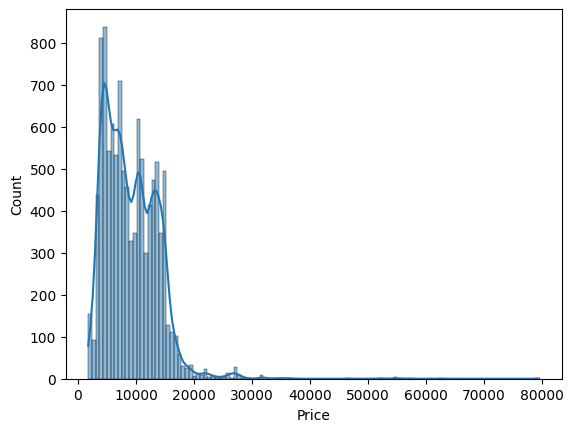

In [29]:
sns.histplot(x=df.Price,kde=True)

#Summary

* All categorical columns show right-skewed or imbalanced distributions.

* Airline, Source, and Destination are dominated by a few categories such as Jet Airways, Delhi, and Cochin.

* Total_Stops is bimodal, concentrated on non-stop and 1-stop flights.

* Additional_Info is highly imbalanced, mostly “No info.”

* Overall, categorical features show skewed frequency distributions that will require proper encoding to prevent bias in modeling.

* The Price feature shows a right-skewed (positively skewed) distribution.

* Most flight prices fall between ₹3,000 - ₹15,000, indicating these are the common fare ranges.

* A few extreme values above ₹40,000.

## 2. Bivariate Analysis

<Axes: xlabel='Price', ylabel='Airline'>

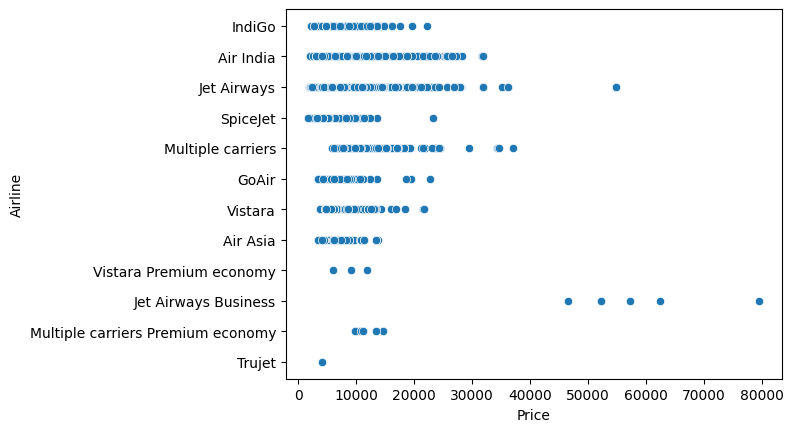

In [30]:
sns.scatterplot(x='Price',y='Airline',data=df)

<Axes: xlabel='Price', ylabel='Source'>

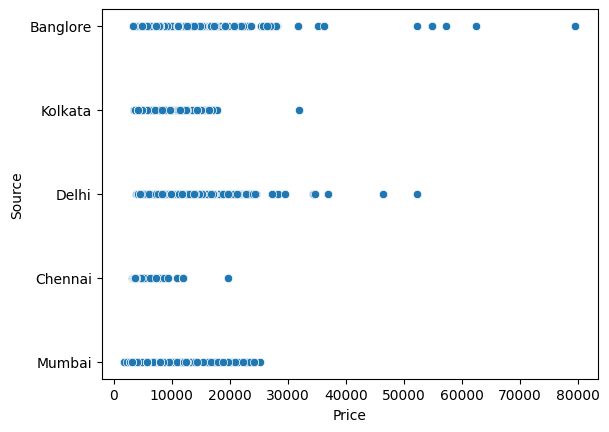

In [31]:
sns.scatterplot(y='Source',x='Price',data=df)

<Axes: xlabel='Price', ylabel='Destination'>

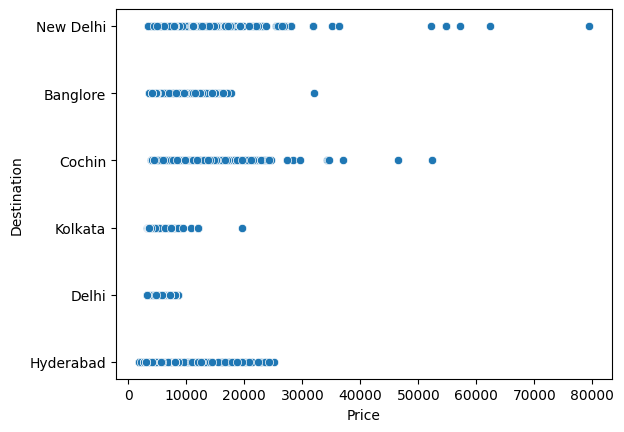

In [32]:
sns.scatterplot(y='Destination',x='Price',data=df)

<Axes: xlabel='Price', ylabel='Total_Stops'>

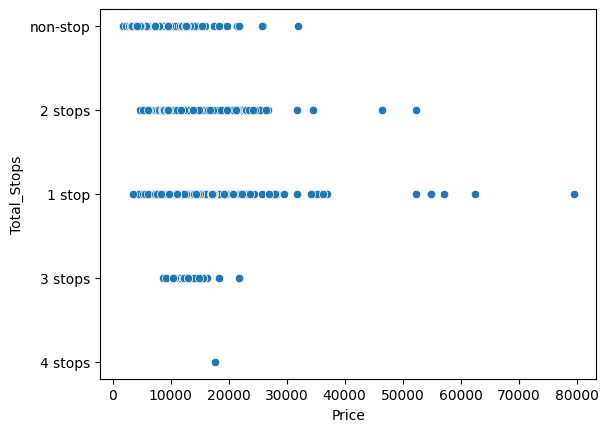

In [33]:
sns.scatterplot(y='Total_Stops',x='Price',data=df)

<Axes: xlabel='Price', ylabel='Additional_Info'>

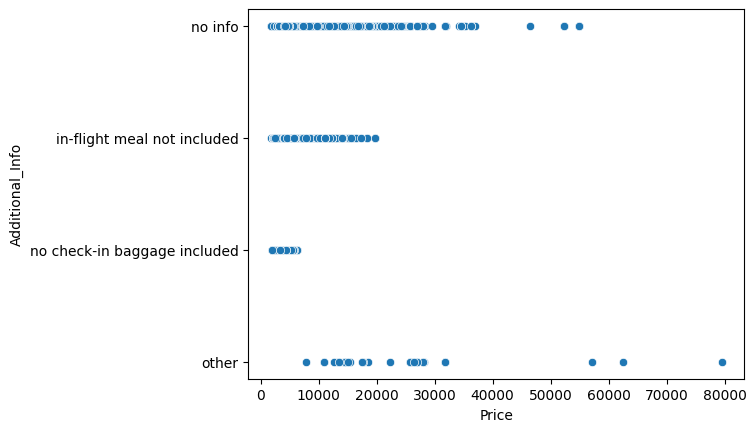

In [34]:
sns.scatterplot(y='Additional_Info',x='Price',data=df)

# Summary

* Airline vs Price: Airlines like Jet Airways, Air India, and Multiple Carriers show higher ticket prices, while IndiGo and SpiceJet generally have lower fares.

* Source vs Price: Flights departing from Delhi and Kolkata tend to have higher prices compared to Mumbai or Chennai.

* Destination vs Price: Cochin and Bangalore are destinations with higher price ranges, showing route-based fare differences.

* Total_Stops vs Price: The price increases with the number of stops — multi-stop flights (2-3 stops) cost more than non-stop ones.

* Additional_Info vs Price: Flights with “In-flight meal not included” or “No check-in baggage included” tend to have slightly lower prices compared to others.

##  To check duration column we have to convert data into minutes so that give us good information.

In [35]:
def convert_to_minutes(duration):
    duration = duration.strip()
    hours = 0
    minutes = 0

    if 'h' in duration:
        hours = int(duration.split('h')[0])
    if 'm' in duration:
        minutes = int(duration.split('h')[-1].replace('m', '').strip() or 0)

    return hours * 60 + minutes

df['Duration_mins'] = df['Duration'].apply(convert_to_minutes)

In [36]:
df.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Duration_mins
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,no info,3897,170
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,no info,7662,445


<Axes: xlabel='Duration_mins', ylabel='Price'>

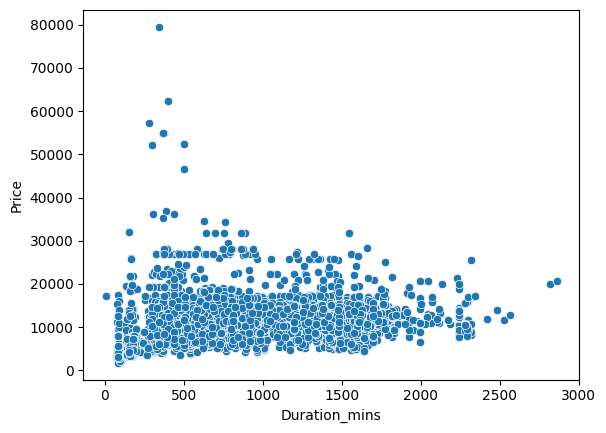

In [37]:
sns.scatterplot(x='Duration_mins',y='Price',data=df)

* The scatterplot shows a weak or almost no positive relationship between flight duration and ticket price.

* Prices do not increase consistently with longer durations — many short flights are expensive, and several long flights are relatively cheap.

* This suggests that duration alone doesn’t strongly influence price, and other factors such as airline type, total stops, and route play a bigger role.

## Data preprocessing

<Axes: xlabel='Duration_mins'>

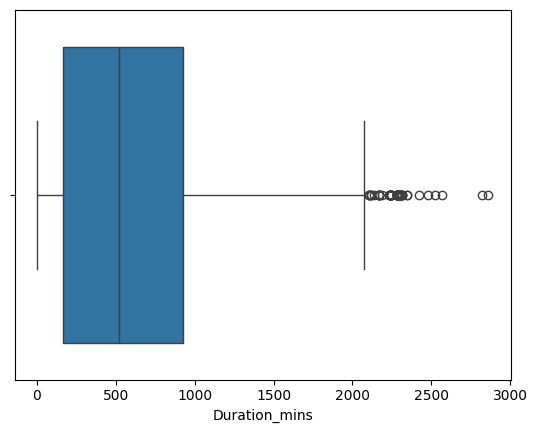

In [38]:
#checking for outliers
sns.boxplot(x=df.Duration_mins)

In [39]:

q1 = df['Duration_mins'].quantile(0.25)
q3 = df['Duration_mins'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
Upper_bound = q3 + 1.5 * iqr

In [40]:
lower_bound

np.float64(-970.0)

In [41]:
Upper_bound

np.float64(2070.0)

In [42]:
df.loc[(df['Duration_mins'] > Upper_bound) | (df['Duration_mins'] < lower_bound)]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Duration_mins
226,Jet Airways,3/03/2019,Delhi,Cochin,DEL → IDR → BOM → COK,05:25,18:50 04 Mar,37h 25m,2 stops,no info,18799,2245
553,Air India,9/03/2019,Delhi,Cochin,DEL → AMD → BOM → COK,05:00,19:15 10 Mar,38h 15m,2 stops,no info,10598,2295
919,Air India,12/05/2019,Kolkata,Banglore,CCU → BBI → IXR → DEL → BLR,12:00,23:15 13 May,35h 15m,3 stops,no info,10991,2115
925,Jet Airways,6/03/2019,Delhi,Cochin,DEL → DED → BOM → COK,16:50,04:25 08 Mar,35h 35m,2 stops,no info,19907,2135
966,Air India,21/05/2019,Delhi,Cochin,DEL → NAG → BOM → COK,05:55,19:15 22 May,37h 20m,2 stops,no info,10493,2240
...,...,...,...,...,...,...,...,...,...,...,...,...
9848,Air India,01/03/2019,Banglore,New Delhi,BLR → BOM → AMD → DEL,08:50,23:55 02 Mar,39h 5m,2 stops,no info,17135,2345
10020,Air India,9/05/2019,Delhi,Cochin,DEL → AMD → BOM → COK,05:00,19:15 10 May,38h 15m,2 stops,no info,9653,2295
10326,Air India,03/03/2019,Banglore,New Delhi,BLR → CCU → GAU → DEL,05:50,22:10 07 Mar,40h 20m,2 stops,no info,11791,2420
10456,Jet Airways,6/03/2019,Delhi,Cochin,DEL → AMD → BOM → COK,19:10,18:50 08 Mar,47h 40m,2 stops,no info,20694,2860


In [43]:
median_value = df['Duration_mins'].median()

In [44]:
median_value

520.0

In [45]:
df.loc[(df['Duration_mins'] > Upper_bound) | (df['Duration_mins'] < lower_bound), 'Duration_mins'] = median_value


* Outliers were detected in the Duration_mins column using the Interquartile Range (IQR) method.

* A total of 73 outlier records were identified, with durations exceeding approximately 2000–2800 minutes (33-47 hours).

* These extremely long flight durations are rare and likely represent multi-stop or delayed flights, which can distort model training.

* Replacing outliers with the median helps reduce skewness in the data and prevents the model from being biased toward extreme durations.

In [46]:
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Duration_mins
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,no info,3897,170
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,no info,7662,445
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,no info,13882,1140
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,no info,6218,325
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,no info,13302,285
...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,no info,4107,150
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,no info,4145,155
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,no info,7229,180
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,no info,12648,160


* Now for Date of Journey column we split that into day and month column.

In [47]:
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'], dayfirst=True, errors='coerce')
df['Journey_Day'] = df['Date_of_Journey'].dt.day
df['Journey_Month'] = df['Date_of_Journey'].dt.month


In [48]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Duration_mins,Journey_Day,Journey_Month
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,no info,3897,170,24,3
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,no info,7662,445,1,5
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,no info,13882,1140,9,6
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,no info,6218,325,12,5
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,no info,13302,285,1,3


* We separated the Dep_Time column into two new columns - Dep_Hour and Dep_Min - to make the dataset cleaner and more structured for analysis.

* This helps the model understand time-of-day patterns (e.g., morning, afternoon, night flights) more effectively.

In [49]:
df['Dep_Hour'] = pd.to_datetime(df['Dep_Time']).dt.hour
df['Dep_Min'] = pd.to_datetime(df['Dep_Time']).dt.minute

* We separated the Arrival_Time column into two new columns - Arrival_Hour and Arrival_Minute — to make it easier to analyze time-based patterns.

* The arrival date part is not considered, because the Duration column already captures total travel time (including next-day arrivals).

* The goal is to observe whether the arrival time of the flight (day vs. night) has any impact on ticket price.

In [50]:
df['Arrival_Hour'] = pd.to_datetime(df['Arrival_Time']).dt.hour
df['Arrival_Min'] = pd.to_datetime(df['Arrival_Time']).dt.minute

In [51]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Duration_mins,Journey_Day,Journey_Month,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,no info,3897,170,24,3,22,20,1,10
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,no info,7662,445,1,5,5,50,13,15
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,no info,13882,1140,9,6,9,25,4,25
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,no info,6218,325,12,5,18,5,23,30
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,no info,13302,285,1,3,16,50,21,35


* After extracting useful information from Date_of_Journey, Dep_Time, and Arrival_Time, we created new columns - Journey_Day, Journey_Month, Dep_Hour, Dep_Minute, Arrival_Hour, and Arrival_Minute.
Since all the important details were captured in these new columns, we dropped the original columns (Date_of_Journey, Dep_Time, Arrival_Time, and Duration) to avoid redundancy and maintain a clean, well-structured dataset for modeling.

In [52]:
df.drop(['Date_of_Journey','Dep_Time','Arrival_Time','Duration'],axis=1,inplace=True)

* Since all the information from the Route column is already captured in the Source, Destination, and Duration columns, we dropped the Route column to eliminate redundancy and keep the dataset simpler and more efficient for modeling.

In [53]:
df.drop(['Route'],axis=1,inplace=True)

# Categorical to Numerical conversion

In [54]:
df.head()

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Duration_mins,Journey_Day,Journey_Month,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min
0,IndiGo,Banglore,New Delhi,non-stop,no info,3897,170,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,2 stops,no info,7662,445,1,5,5,50,13,15
2,Jet Airways,Delhi,Cochin,2 stops,no info,13882,1140,9,6,9,25,4,25
3,IndiGo,Kolkata,Banglore,1 stop,no info,6218,325,12,5,18,5,23,30
4,IndiGo,Banglore,New Delhi,1 stop,no info,13302,285,1,3,16,50,21,35


* We used Ordinal Encoding for Total_Stops because this feature naturally represents an ordered sequence (non-stop < 1 stop < 2 stops < …).
Increasing number of stops typically increases flight duration and price, so preserving this order helps the model learn better.

In [55]:
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder()
df['Total_Stops']= oe.fit_transform(df[['Total_Stops']])

* Columns like Airline, Source, Destination, and Additional_Info have no ranking - so we use one hot encoder.

In [56]:
df = pd.get_dummies(df, columns=['Airline', 'Source', 'Destination', 'Additional_Info'],dtype=int, drop_first=True)

In [57]:
df.head()

,Total_Stops,Price,Duration_mins,Journey_Day,Journey_Month,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Airline_Air India,...,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi,Additional_Info_no check-in baggage included,Additional_Info_no info,Additional_Info_other
0,4.0,3897,170,24,3,22,20,1,10,0,...,0,0,0,0,0,0,1,0,1,0
1,1.0,7662,445,1,5,5,50,13,15,1,...,1,0,0,0,0,0,0,0,1,0
2,1.0,13882,1140,9,6,9,25,4,25,0,...,0,0,1,0,0,0,0,0,1,0
3,0.0,6218,325,12,5,18,5,23,30,0,...,1,0,0,0,0,0,0,0,1,0
4,0.0,13302,285,1,3,16,50,21,35,0,...,0,0,0,0,0,0,1,0,1,0


# Feature Selection

<Axes: >

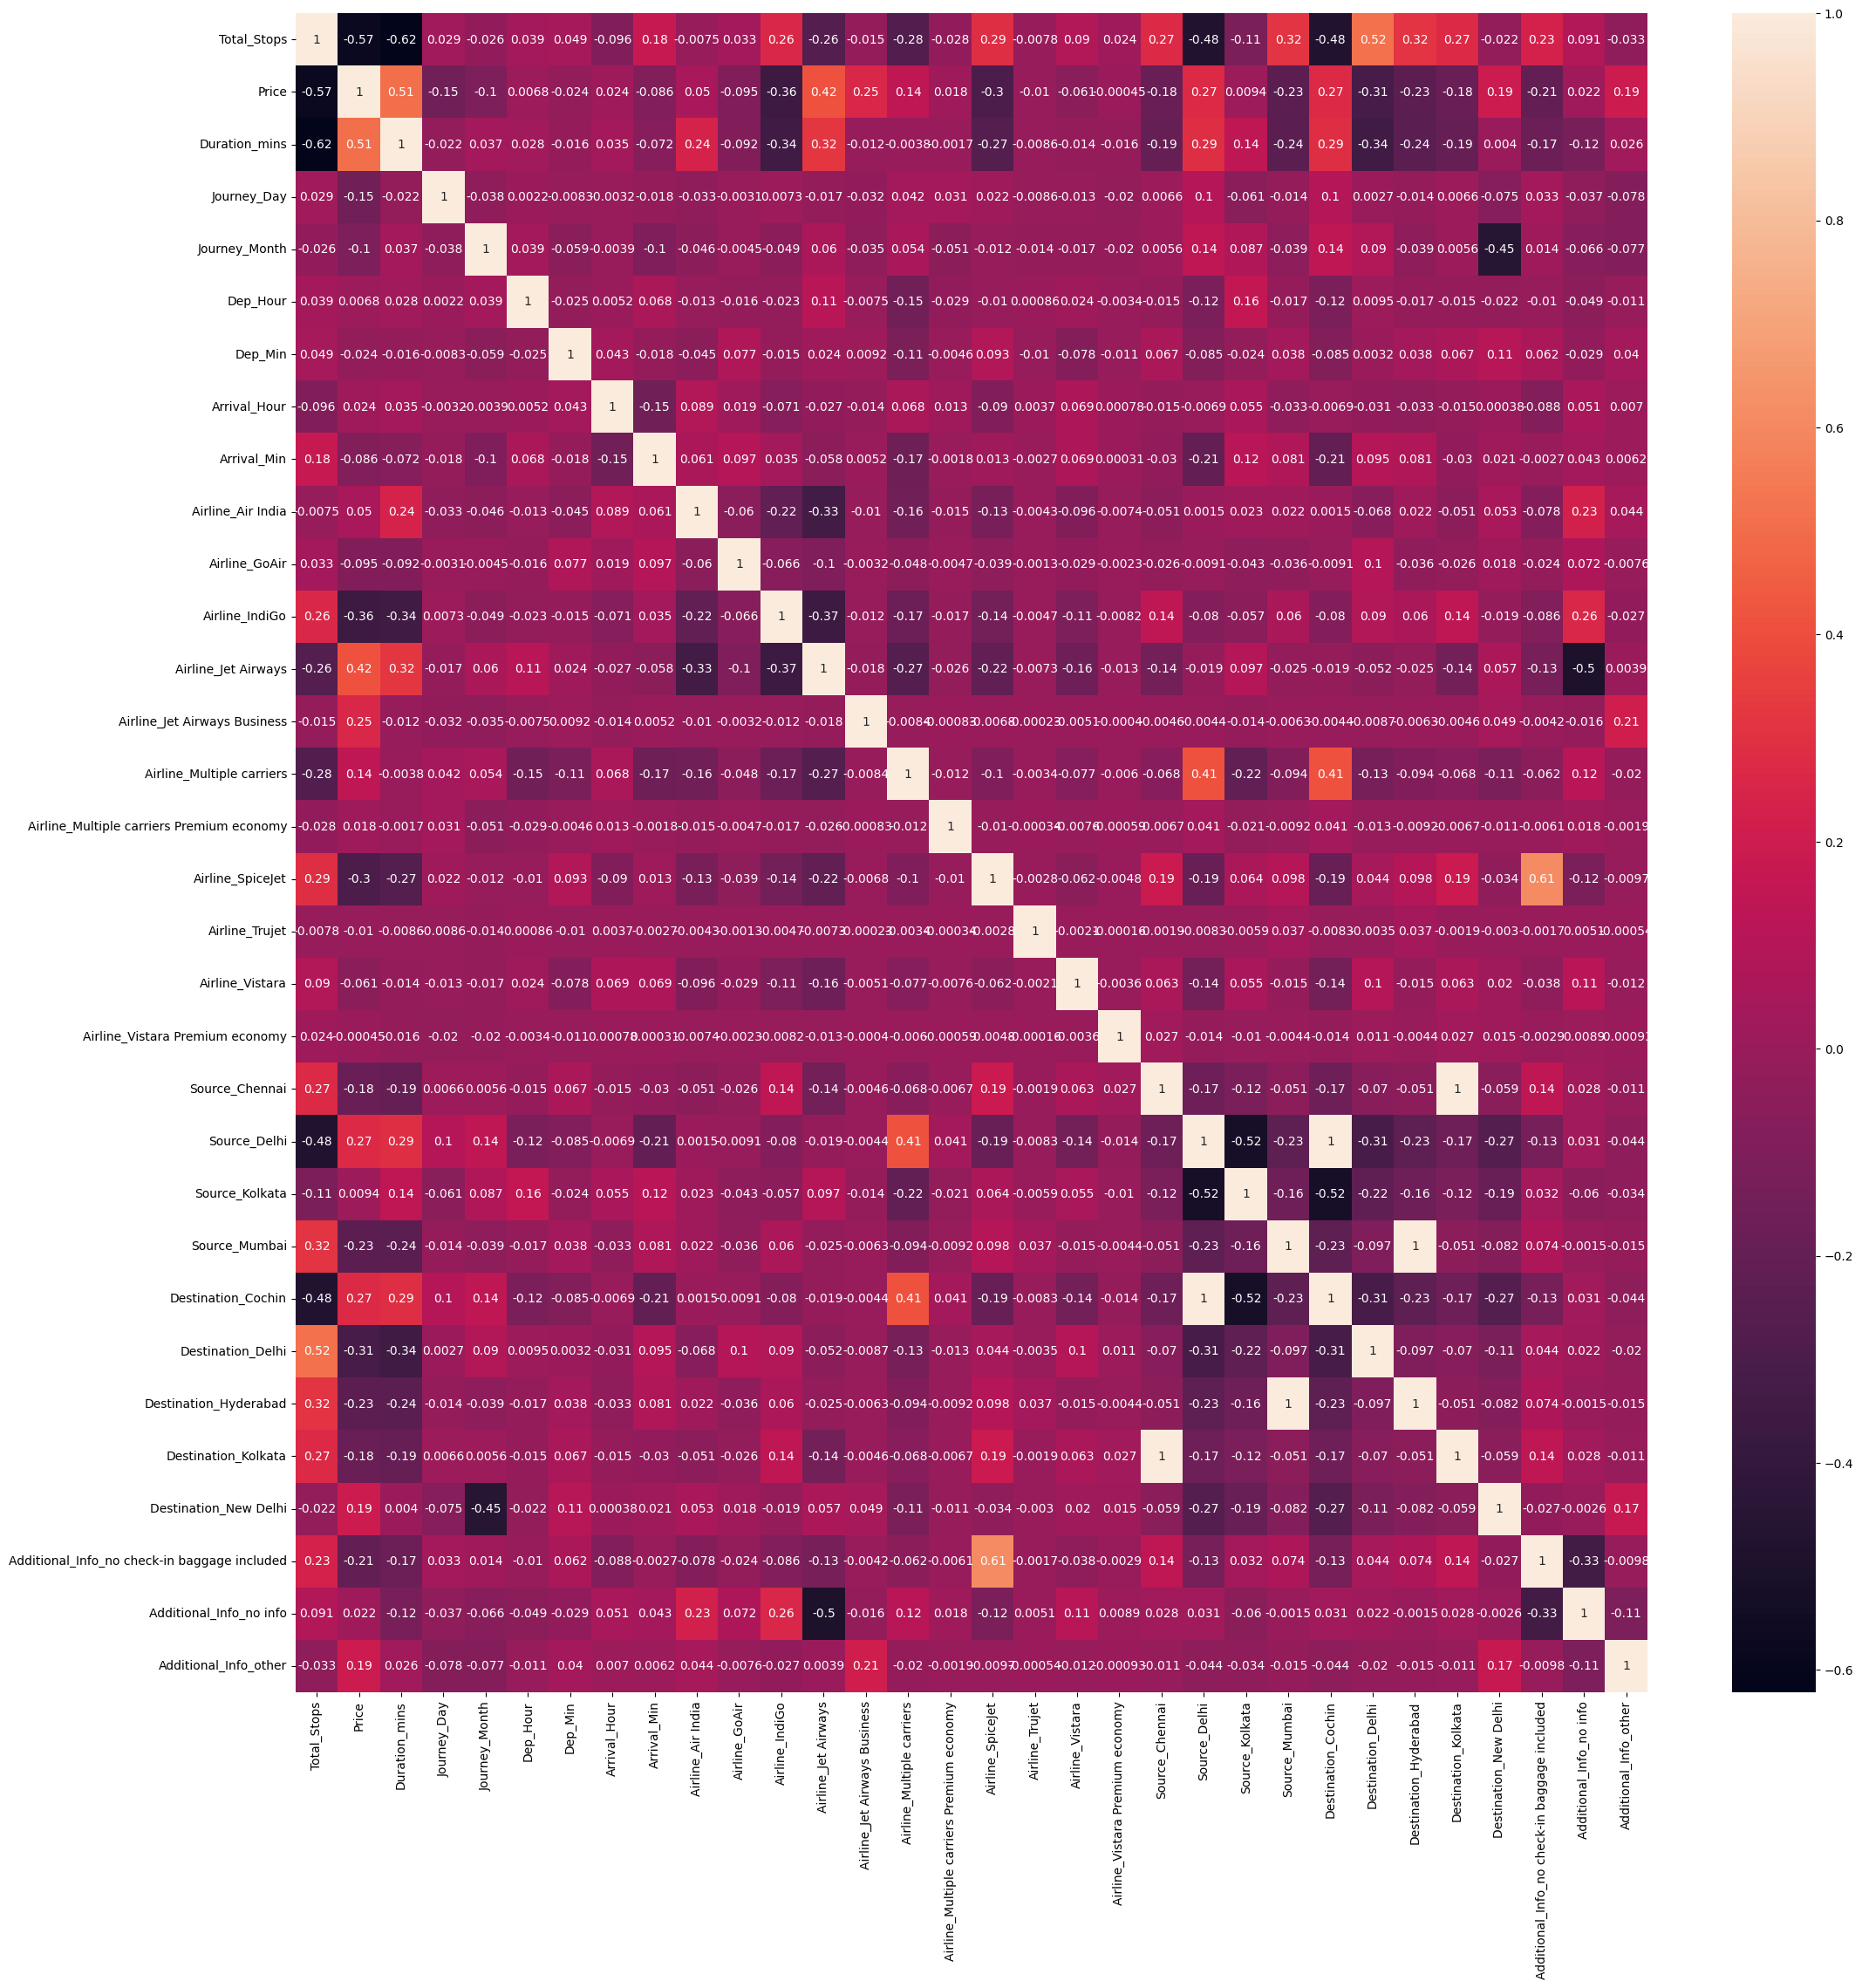

In [58]:
plt.figure(figsize=(25,25))
sns.heatmap(df.corr(),annot=True)

* Based on the correlation heatmap, there are no strongly correlated features among the remaining columns. Therefore, no additional feature needs to be removed, and all current columns can be retained for model building.

# Scaling

In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cols_to_scale = ['Duration_mins', 'Journey_Day', 'Journey_Month',
                 'Dep_Hour', 'Dep_Min', 'Arrival_Hour', 'Arrival_Min','Total_Stops']

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

In [60]:
df.head()

,Total_Stops,Price,Duration_mins,Journey_Day,Journey_Month,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Airline_Air India,...,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi,Additional_Info_no check-in baggage included,Additional_Info_no info,Additional_Info_other
0,1.407309,3897,-0.942235,1.237383,-1.467490,1.654259,-0.235050,-1.800427,-0.890057,0,...,0,0,0,0,0,0,1,0,1,0
1,-0.253632,7662,-0.380248,-1.475239,0.250276,-1.303095,1.363492,-0.050851,-0.587124,1,...,1,0,0,0,0,0,0,0,1,0
2,-0.253632,13882,1.040045,-0.531719,1.109160,-0.607247,0.031373,-1.363033,0.018744,0,...,0,0,1,0,0,0,0,0,1,0
3,-0.807278,6218,-0.625479,-0.177898,0.250276,0.958411,-1.034321,1.407129,0.321677,0,...,1,0,0,0,0,0,0,0,1,0
4,-0.807278,13302,-0.707222,-1.475239,-1.467490,0.610487,1.363492,1.115533,0.624611,0,...,0,0,0,0,0,0,1,0,1,0


* We applied StandardScaler to the continuous numerical features (Duration_mins, Journey_Day, Journey_Month, Dep_Hour, Dep_Min, Arrival_Hour, Arrival_Min).
* These features are on different numeric scales, so scaling helps models like SVM, ANN, KNN, and Linear Regression learn more effectively.
One-hot encoded columns and the target variable (Price) were not scaled.

# Model Selection

In [61]:
from sklearn.model_selection import train_test_split
X=df.drop('Price',axis=1)
y=df['Price']

In [62]:
from numpy.random.mtrand import random
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=7)

# Model creation and Evaluation

In [63]:
from sklearn.linear_model import LinearRegression
LR = LinearRegression()
LR.fit(X_train,y_train)

LinearRegression()

In [64]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [59]:
y_pred = LR.predict(X_test)

In [60]:
r2_score(y_test,y_pred)

0.6741459647414383

In [61]:
print('mean absolute error:',mean_absolute_error(y_test,y_pred))

mean absolute error: 1808.255740636071


In [62]:
print('mean squared error:',mean_squared_error(y_test,y_pred))

mean squared error: 6440126.789283812


* Linear Regression achieved an R² score of 0.67, indicating that the model explains 67% of the variability in flight prices
* The Linear Regression model achieved an MAE of ₹1808.25 and an MSE of 6.44 million. This indicates moderate performance, with an average prediction error of around ₹1800. The high MSE suggests the presence of some large errors, likely due to the non-linear nature of flight pricing. Therefore, advanced models such as Random Forest and Gradient Boosting may perform better.

# SVM Model

In [ ]:
from sklearn.svm import SVR

svm_model = SVR(kernel='rbf')   # rbf kernel works best for non-linear data
svm_model.fit(X_train, y_train)


SVR()

In [ ]:
y_pred_svm = svm_model.predict(X_test)

In [ ]:
print("MAE:", mean_absolute_error(y_test, y_pred_svm))
print("MSE:", mean_squared_error(y_test, y_pred_svm))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_svm)))
print("R2 Score:", r2_score(y_test, y_pred_svm))

MAE: 3351.8815273346077
MSE: 18645837.086952083
RMSE: 4318.082570650089
R2 Score: 0.0565680685561849


* SVR performed poorly on the flight price dataset, achieving an R² score of only 0.05 and an MAE of ₹3351. This is due to the large dataset size, high feature complexity, and the sensitivity of SVR to hyperparameters.

# Hyper parameter tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [1, 10, 50, 100],
    'gamma': ['scale', 'auto', 0.01, 0.001],
    'kernel': ['rbf']
}

grid = GridSearchCV(SVR(), param_grid, cv=3, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

print(grid.best_params_)
best_svm = grid.best_estimator_


{'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}


In [ ]:
y_pred_svm_hpt = best_svm.predict(X_test)

In [ ]:
print("MAE:", mean_absolute_error(y_test, y_pred_svm_hpt))
print("MSE:", mean_squared_error(y_test, y_pred_svm_hpt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_svm_hpt)))
print("R2 Score:", r2_score(y_test, y_pred_svm_hpt))

MAE: 1646.3630419389776
MSE: 7264847.854962781
RMSE: 2695.3381707983845
R2 Score: 0.632417176472641


* After hyperparameter tuning, the SVR model achieved an MAE of ₹1646 and an R² score of 0.63, showing significant improvement over the default SVR model. The tuned SVR now performs comparably to Linear Regression, indicating that it can capture non-linear relationships in the data to a moderate extent.

# Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor
RFR = RandomForestRegressor(random_state=7)
RFR.fit(X_train,y_train)

RandomForestRegressor(random_state=7)

In [ ]:
y_pred_rfr = RFR.predict(X_test)

In [ ]:
print("MAE:", mean_absolute_error(y_test, y_pred_rfr))
print("MSE:", mean_squared_error(y_test, y_pred_rfr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rfr)))
print("R2 Score:", r2_score(y_test, y_pred_rfr))

MAE: 615.9245282011573
MSE: 1675847.4795535994
RMSE: 1294.5452790665915
R2 Score: 0.9152063800049566


#Hyper parameter tuning of Random forest regressor

In [ ]:
params = {'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 5, 10, 15, 20, 25],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']}

In [4]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
RFR_HPT = RandomizedSearchCV(
    estimator=RFR,
    param_distributions=params,
    n_iter=20,
    scoring='r2',
    cv=3,
    verbose=1,
    random_state=7,
    n_jobs=-1
)

RFR_HPT.fit(X_train, y_train)

print("Best Parameters from Random Search:")
print(RFR_HPT.best_params_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters from Random Search:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}


In [ ]:
y_pred_rfr_hpt = RFR_HPT.predict(X_test)

In [ ]:
print("MAE:", mean_absolute_error(y_test, y_pred_rfr_hpt))
print("MSE:", mean_squared_error(y_test, y_pred_rfr_hpt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rfr_hpt)))
print("R2 Score:", r2_score(y_test, y_pred_rfr_hpt))

MAE: 775.2634562925458
MSE: 1804951.7240006854
RMSE: 1343.4849176677367
R2 Score: 0.9086740336089054


# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeRegressor
DTR = DecisionTreeRegressor(random_state=7)
DTR.fit(X_train,y_train)

DecisionTreeRegressor(random_state=7)

In [ ]:
y_pred_dtr = DTR.predict(X_test)

In [ ]:
print("MAE:", mean_absolute_error(y_test, y_pred_dtr))
print("MSE:", mean_squared_error(y_test, y_pred_dtr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dtr)))
print("R2 Score:", r2_score(y_test, y_pred_dtr))

MAE: 752.4893542349088
MSE: 5209534.351339495
RMSE: 2282.440437632381
R2 Score: 0.7364108121245782


# Ensemble techniques of Decision Tree

## Bagging

In [ ]:
from sklearn.ensemble import BaggingRegressor
bagging = DecisionTreeRegressor(random_state=7)

bagging_model = BaggingRegressor(
    estimator=bagging,
    n_estimators=100,      # number of trees
    max_samples=0.8,       # 80% of data per tree
    max_features=1.0,      # use all features
    bootstrap=True,
    n_jobs=-1,
    random_state=7
)

In [ ]:
bagging_model.fit(X_train, y_train)

BaggingRegressor(estimator=DecisionTreeRegressor(random_state=7),
                 max_samples=0.8, n_estimators=100, n_jobs=-1, random_state=7)

In [ ]:
y_pred_bagging = bagging_model.predict(X_test)

In [ ]:
print("MAE:", mean_absolute_error(y_test, y_pred_bagging))
print("MSE:", mean_squared_error(y_test, y_pred_bagging))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_bagging)))
print("R2 Score:", r2_score(y_test, y_pred_bagging))

MAE: 624.3518242678135
MSE: 1619142.2268591204
RMSE: 1272.455196405406
R2 Score: 0.9180755215631009


## Boosting

In [63]:
from sklearn.ensemble import GradientBoostingRegressor

boosting = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=7
)

In [64]:
boosting.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=200, random_state=7)

In [65]:
y_pred_boosting = boosting.predict(X_test)

In [67]:
print("MAE:", mean_absolute_error(y_test, y_pred_boosting))
print("MSE:", mean_squared_error(y_test, y_pred_boosting))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_boosting)))
print("R2 Score:", r2_score(y_test,y_pred_boosting ))

MAE: 1215.08158257933
MSE: 3212421.32452922
RMSE: 1792.3228851212104
R2 Score: 0.8374596516810332


#XGBoost

In [68]:
!pip install xgboost

In [69]:
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=7)

In [70]:
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [71]:
y_pred_xgb = xgb.predict(X_test)

In [72]:
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("MSE:", mean_squared_error(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("R2 Score:", r2_score(y_test,y_pred_xgb ))

MAE: 699.4174194335938
MSE: 1476351.875
RMSE: 1215.0522108123585
R2 Score: 0.9253003597259521


# Hyper Parameter Tuning of XGB

In [75]:
param_dist = {
    'n_estimators': [200, 300, 500, 700, 900],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [4, 5, 6, 7, 8, 10],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1],
    'min_child_weight': [1, 2, 3, 5, 7]
}

In [76]:


xgb_hpt = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,             # try 20 random combinations
    scoring='r2',
    cv=3,
    verbose=1,
    random_state=7,
    n_jobs=-1
)

xgb_hpt.fit(X_train, y_train)

print("Best Parameters:")
print(xgb_hpt.best_params_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters:
{'subsample': 0.7, 'n_estimators': 700, 'min_child_weight': 3, 'max_depth': 10, 'learning_rate': 0.03, 'colsample_bytree': 0.7}


In [77]:
y_pred_xgb_hpt = xgb_hpt.predict(X_test)

In [78]:
print("MAE:", mean_absolute_error(y_test, y_pred_xgb_hpt))
print("MSE:", mean_squared_error(y_test, y_pred_xgb_hpt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb_hpt)))
print("R2 Score:", r2_score(y_test,y_pred_xgb_hpt ))

MAE: 609.4920654296875
MSE: 1381291.5
RMSE: 1175.2835828003385
R2 Score: 0.9301101565361023


#ANN

In [2]:
from sklearn.neural_network import MLPRegressor

In [81]:
ann = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=500, random_state=7)

In [82]:
ann.fit(X_train, y_train)

MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=7)

In [83]:
y_pred_ann = ann.predict(X_test)

In [84]:
print("MAE:", mean_absolute_error(y_test, y_pred_ann))
print("MSE:", mean_squared_error(y_test, y_pred_ann))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ann)))
print("R2 Score:", r2_score(y_test,y_pred_ann ))

MAE: 1290.5638933827383
MSE: 3869952.77545799
RMSE: 1967.2195544620813
R2 Score: 0.8041902326765692


#Hyper Parameter Tuning of ANN

In [1]:
params = {'hidden_layer_sizes': [(64,32), (128,64), (128,64,32)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01, 0.05],
    'max_iter': [500, 800, 1000]}

In [65]:
mlp = MLPRegressor(random_state=7)

ann_hpt = RandomizedSearchCV(
    estimator=mlp,
    param_distributions=params,
    n_iter=10,
    scoring='r2',
    cv=3,
    verbose=1,
    random_state=7,
    n_jobs=-1
)
ann_hpt.fit(X_train, y_train)

print("Best Parameters:")
print(ann_hpt.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters:
{'solver': 'adam', 'max_iter': 500, 'learning_rate_init': 0.001, 'hidden_layer_sizes': (128, 64, 32), 'alpha': 0.001, 'activation': 'relu'}


In [66]:
y_pred_ann_hpt = ann_hpt.predict(X_test)

In [67]:
print("MAE:", mean_absolute_error(y_test, y_pred_ann_hpt))
print("MSE:", mean_squared_error(y_test, y_pred_ann_hpt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ann_hpt)))
print("R2 Score:", r2_score(y_test,y_pred_ann_hpt ))

MAE: 1019.2810933785235
MSE: 2432142.837052972
RMSE: 1559.5328906608454
R2 Score: 0.8769397585312055


#Comparision of all Model

In [68]:
data = {
    'Model': ['Linear Regression','SVR (Default)','SVR (Tuned)','Decision Tree',
              'Bagging Regressor','Random Forest','Random Forest (Tuned)','Gradient Boosting','XGBoost (Default)',
        'XGBoost (Tuned)','ANN (Normal)','ANN (Tuned)'],
    'R2 Score': [0.67,0.05,0.63,0.736,0.918,0.915,0.908,0.837,0.925,0.930,0.804,0.877],
    'MAE': [1808,3351,1646,752,624,615,775,1215,699,609,1291,1019]
}

df_compare = pd.DataFrame(data)

# Sort by R2 Score (descending)
df_compare = df_compare.sort_values(by='R2 Score', ascending=False).reset_index(drop=True)

df_compare

,Model,R2 Score,MAE
0,XGBoost (Tuned),0.930,609
1,XGBoost (Default),0.925,699
2,Bagging Regressor,0.918,624
3,Random Forest,0.915,615
4,Random Forest (Tuned),0.908,775
5,ANN (Tuned),0.877,1019
6,Gradient Boosting,0.837,1215
7,ANN (Normal),0.804,1291
8,Decision Tree,0.736,752
9,Linear Regression,0.670,1808


* XGBoost (Tuned) achieved the highest performance with an R² score of 0.93 and the lowest MAE of 609, making it the best model for predicting flight prices.
* Bagging Regressor and Random Forest also performed strongly (R² ≈ 0.91+), showing that tree-based ensemble methods outperform linear and kernel-based models on this dataset.

#Conclusion

* In this project, we analyzed various machine learning models to predict flight prices using a combination of engineered numerical features and encoded categorical variables. The comparative study shows that tree-based ensemble models significantly outperform linear and kernel-based models due to the non-linear and complex structure of the dataset.

* Tuned XGBoost performed the best, achieving an R² score of 0.93 and the lowest MAE, making it the most accurate model for flight price prediction.

* Random Forest and Bagging Regressor also gave strong results (R² ≈ 0.91+), showing that ensemble models handle non-linear data very effectively.

* ANN (tuned) performed moderately well (R² ≈ 0.87) but did not outperform tree-based models.

* Linear Regression, SVR, and Decision Tree showed lower accuracy, proving that simple or linear models cannot capture complex relationships in flight data.

* Feature engineering (duration, time extraction, encoding) significantly improved model performance.

* Outlier handling and scaling helped stabilize models, especially ANN and SVR.

## Final Model Recommendation

* Overall, XGBoost is recommended as the final model due to its high accuracy, generalization ability, and robustness.

# Future Scope

* Additional features like holiday indicators, weather conditions, demand patterns, or seat availability can further improve prediction accuracy.


# Chalanges Faced
* Handling multiple categorical columns required careful encoding to avoid high dimensionality and incorrect model learning.

* Cleaning and converting complex features like Duration, Arrival_Time, and Dep_Time into usable numerical formats was challenging and required multiple preprocessing steps.

* Outliers in Duration_mins and Price needed proper identification and treatment to prevent model distortion.

* Selecting appropriate models and tuning them was difficult due to the non-linear nature of flight pricing, leading to varied performance across algorithms.